In [64]:
import pandas as pd

In [65]:
ground_truth_0 = pd.read_csv('data/ground_truth/dataset_label_0_with_categories.csv')
ground_truth_1 = pd.read_csv('data/ground_truth/dataset_label_1_with_categories.csv')
synthetic_0 = pd.read_csv('data/synthetic/synthetic_label_0.csv')
synthetic_1 = pd.read_csv('data/synthetic/synthetic_label_1.csv')

In [66]:
print("Số lượng mẫu trong từng tập dữ liệu:")
print(f"ground_truth_0: {len(ground_truth_0)}")
print(f"ground_truth_1: {len(ground_truth_1)}")
print(f"synthetic_0:    {len(synthetic_0)}")
print(f"synthetic_1:    {len(synthetic_1)}")

Số lượng mẫu trong từng tập dữ liệu:
ground_truth_0: 2327
ground_truth_1: 275
synthetic_0:    3000
synthetic_1:    5000


In [67]:
# Thống kê phân phối category (số lượng & tỉ lệ phần trăm)
if 'category_label' in ground_truth_0.columns:
    category_counts = ground_truth_0['category_label'].value_counts(dropna=False)
    category_percent = ground_truth_0['category_label'].value_counts(normalize=True, dropna=False) * 100
    category_dist = pd.DataFrame({
        'Số lượng': category_counts,
        'Tỉ lệ (%)': category_percent.round(2)
    })
    print("Phân phối category (số lượng và tỉ lệ %):")
    print(category_dist)
else:
    print("Không tìm thấy cột 'category_label' trong dữ liệu.")

Phân phối category (số lượng và tỉ lệ %):
                    Số lượng  Tỉ lệ (%)
category_label                         
Viễn thông              1061      45.60
Khác                     507      21.79
Cá nhân & OTP            302      12.98
Dịch vụ công thật        174       7.48
Quảng cáo hợp lệ         136       5.84
Ngân hàng thật           126       5.41
Vận chuyển                18       0.77
Y tế                       2       0.09
Thương mại điện tử         1       0.04


In [68]:
# Drop cột "category_label" nếu tồn tại trong ground_truth_1
if "category_label" in ground_truth_1.columns:
    ground_truth_1 = ground_truth_1.drop(columns=["category_label"])

# Thống kê phân phối "smishing_type"
if "smishing_type" in ground_truth_1.columns:
    smishing_counts = ground_truth_1["smishing_type"].value_counts(dropna=False)
    smishing_percent = ground_truth_1["smishing_type"].value_counts(normalize=True, dropna=False) * 100
    smishing_dist = pd.DataFrame({
        "Số lượng": smishing_counts,
        "Tỉ lệ (%)": smishing_percent.round(2)
    })
    print("Phân phối smishing_type (số lượng và tỉ lệ %):")
    print(smishing_dist)
else:
    print("Không tìm thấy cột 'smishing_type' trong dữ liệu.")

Phân phối smishing_type (số lượng và tỉ lệ %):
                   Số lượng  Tỉ lệ (%)
smishing_type                         
Khác                     74      26.91
Giả mạo ngân hàng        66      24.00
Cờ bạc/Betting           53      19.27
Tuyển dụng giả           27       9.82
Dịch vụ công giả         16       5.82
BHXH/Trợ cấp giả         15       5.45
Đòi nợ/Đe doạ            12       4.36
Nội dung nhạy cảm        10       3.64
Đầu tư/Crypto giả         2       0.73


In [69]:
if 'category_label' in ground_truth_0.columns:
    mask = ground_truth_0['category_label'] == "Thương mại điện tử"
    print(ground_truth_0[mask])
else:
    print("Không tìm thấy cột 'category_label' trong dữ liệu.")

                                                content  label  has_url  \
1036  Do anh huong cua Covid-19,  DH 299325121788280...      0        0   

      has_phone_number sender_type      category_label  
1036                 0   brandname  Thương mại điện tử  


In [70]:
if 'category_label' in ground_truth_0.columns:
    subset = ground_truth_0.loc[
        ground_truth_0['category_label'] == "Cá nhân & OTP",
        ["content"]
    ].reset_index()

    print(f"Tổng số tin nhắn: {len(subset)}\n")
    for i, row in subset.iterrows():
        print(f"--- Tin {i+1} | index gốc: {row['index']} ---")
        print(row["content"])
        print()
else:
    print("Không tìm thấy cột 'category_label' trong dữ liệu.")

Tổng số tin nhắn: 302

--- Tin 1 | index gốc: 0 ---
Hương đang làm gì vậy? Dạo này công việc thế nào rồi? 

--- Tin 2 | index gốc: 1 ---
Linh ơi anh Tuấn nè, hôm nay vô tình gặp chị Mai nên xin được số em

--- Tin 3 | index gốc: 2 ---
Thảo dạo này khoẻ không, công việc ổn chứ ? 

--- Tin 4 | index gốc: 3 ---
Chào Phương! Bạn và gia đình dạo này khoẻ chứ?

--- Tin 5 | index gốc: 4 ---
Chào Hùng. Lâu rồi không gặp. dạo này công việc vẫn ổn chứ

--- Tin 6 | index gốc: 5 ---
Em Hà day. Goi lai vao so 0978123456 em co viec gap.

--- Tin 7 | index gốc: 6 ---
[VIENDONG] MA otp dang nhap cua ban la 7GJ9VI .Vui long khong chia se cho nguoi khac. - viendongjsc.vn

--- Tin 8 | index gốc: 24 ---
SHOPEE: DE CAP NHAT MAT KHAU, ma xac minh la 131929. Co hieu luc trong 15 phut. KHONG chia se ma nay voi nguoi khac, ke ca nhan vien Shopee.

--- Tin 9 | index gốc: 25 ---
Use code 55167 to add this phone to your Steam account

--- Tin 10 | index gốc: 69 ---
Mã xác thực GitHub của bạn là: 733792

--- Tin 1

In [71]:
# Thống kê metadata theo từng loại sender_type

if all(col in ground_truth_0.columns for col in ['sender_type', 'has_url', 'has_phone_number', 'content']):
    metadata_stats = (
        ground_truth_0.groupby('sender_type')
        .agg(
            total=('sender_type', 'count'),
            rate_has_url=('has_url', lambda x: (x==1).mean() * 100),
            rate_has_phone=('has_phone_number', lambda x: (x==1).mean() * 100),
            mean_content_length=('content', lambda x: x.astype(str).str.len().mean())
        )
        .reset_index()
        .rename(columns={
            'sender_type': 'Loại sender',
            'total': 'Số lượng',
            'rate_has_url': 'Tỷ lệ có URL (%)',
            'rate_has_phone': 'Tỷ lệ có SĐT (%)',
            'mean_content_length': 'Content length (mean)'
        })
    )

    print("Thống kê metadata theo từng loại sender_type:")
    print(metadata_stats.to_string(index=False, float_format="%.2f"))
else:
    print("Thiếu một số cột cần thiết trong dữ liệu (yêu cầu: sender_type, has_url, has_phone_number, content)")

Thống kê metadata theo từng loại sender_type:
    Loại sender  Số lượng  Tỷ lệ có URL (%)  Tỷ lệ có SĐT (%)  Content length (mean)
      brandname      1759             53.72             41.56                 235.63
personal_number       106              3.77              4.72                  80.80
      shortcode       462             40.04             48.27                 237.82


## Word Cloud

In [72]:
%pip install underthesea wordcloud matplotlib

Note: you may need to restart the kernel to use updated packages.


In [73]:
import os
import re
import unicodedata
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import underthesea
from underthesea import word_tokenize
from wordcloud import WordCloud

In [74]:
# --- Stopwords (theo underthesea) ---
_STOP = Path(underthesea.__file__).parent / "datasets" / "stopwords" / "stopwords.txt"
VI_STOPWORDS = set(_STOP.read_text(encoding="utf-8").splitlines())
VI_STOPWORDS.discard("")
_DIGITS_ONLY = re.compile(r"^\d+$")
# 1–2: Unicode normalize (NFC) + lowercase
def normalize_text(text: str) -> str:
    return unicodedata.normalize("NFC", text or "").lower().strip()
# 4: Tách từ + lọc token rỗng / chỉ số / dấu câu đơn lẻ
def segment_words(text: str) -> list[str]:
    s = normalize_text(text)
    toks = word_tokenize(s)
    out = []
    for t in toks:
        t = t.strip()
        if not t:
            continue
        if _DIGITS_ONLY.match(t):
            continue
        if len(t) == 1 and not t.isalnum():
            continue
        out.append(t)
    return out
# 5: Bỏ stopword
def remove_stopwords(tokens: list[str], stopwords: set[str]) -> list[str]:
    return [t for t in tokens if t not in stopwords]
# 6: Phát hiện cụm = bigram đủ tần suất (trên toàn corpus, đếm trong từng SMS)
def bigram_counts(token_lists: list[list[str]]) -> Counter:
    c = Counter()
    for toks in token_lists:
        c.update(zip(toks, toks[1:]))
    return c
def detect_phrases(token_lists: list[list[str]], min_count: int = 5) -> set[tuple[str, str]]:
    bc = bigram_counts(token_lists)
    return {bg for bg, n in bc.items() if n >= min_count}
def collapse_phrases(tokens: list[str], phrases: set[tuple[str, str]], joiner: str = " ") -> list[str]:
    i, out = 0, []
    while i < len(tokens):
        if i + 1 < len(tokens) and (tokens[i], tokens[i + 1]) in phrases:
            out.append(joiner.join([tokens[i], tokens[i + 1]]))
            i += 2
        else:
            out.append(tokens[i])
            i += 1
    return out
# 7–8: Đếm tần suất + tạo dict cho WordCloud
def build_frequencies(texts: pd.Series | list, min_bigram_count: int = 8) -> tuple[Counter, set]:
    texts = list(texts)
    doc_seg = [segment_words(t) for t in texts]
    doc_ns = [remove_stopwords(d, VI_STOPWORDS) for d in doc_seg]
    phrases = detect_phrases(doc_ns, min_count=min_bigram_count)
    doc_final = [collapse_phrases(d, phrases) for d in doc_ns]
    flat = [w for doc in doc_final for w in doc]
    return Counter(flat), phrases
def pick_vi_font():
    for p in [
        r"C:\Windows\Fonts\arial.ttf",
        r"C:\Windows\Fonts\times.ttf",
        r"C:\Windows\Fonts\msyh.ttc",
    ]:
        if os.path.isfile(p):
            return p
    return None
def show_wordcloud(freq: Counter, title: str = "", max_words: int = 150):
    wc = WordCloud(
        font_path=pick_vi_font(),
        width=1200,
        height=600,
        background_color="white",
        max_words=max_words,
        colormap="viridis",
    ).generate_from_frequencies(dict(freq.most_common(max_words)))
    plt.figure(figsize=(14, 7))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    if title:
        plt.title(title)
    plt.tight_layout()
    plt.show()

Số bigram (phrase): 1417
Top 20: [('tb', 436), ('ngay', 347), ('quý khách', 313), ('nạp thẻ', 268), ('đ', 254), ('ngày', 253), ('khuyến mại sử dụng', 244), ('gọi nhắn', 244), ('tin ngày', 244), ('chi tiet', 224), ('viettel', 174), ('cskh đ', 171), ('vui long', 155), ('tai khoan', 146), ('goi cuoc', 146), ('cua quy khach', 139), ('cho', 136), ('d ngay', 130), ('tran', 119), ('lh đ', 119)]


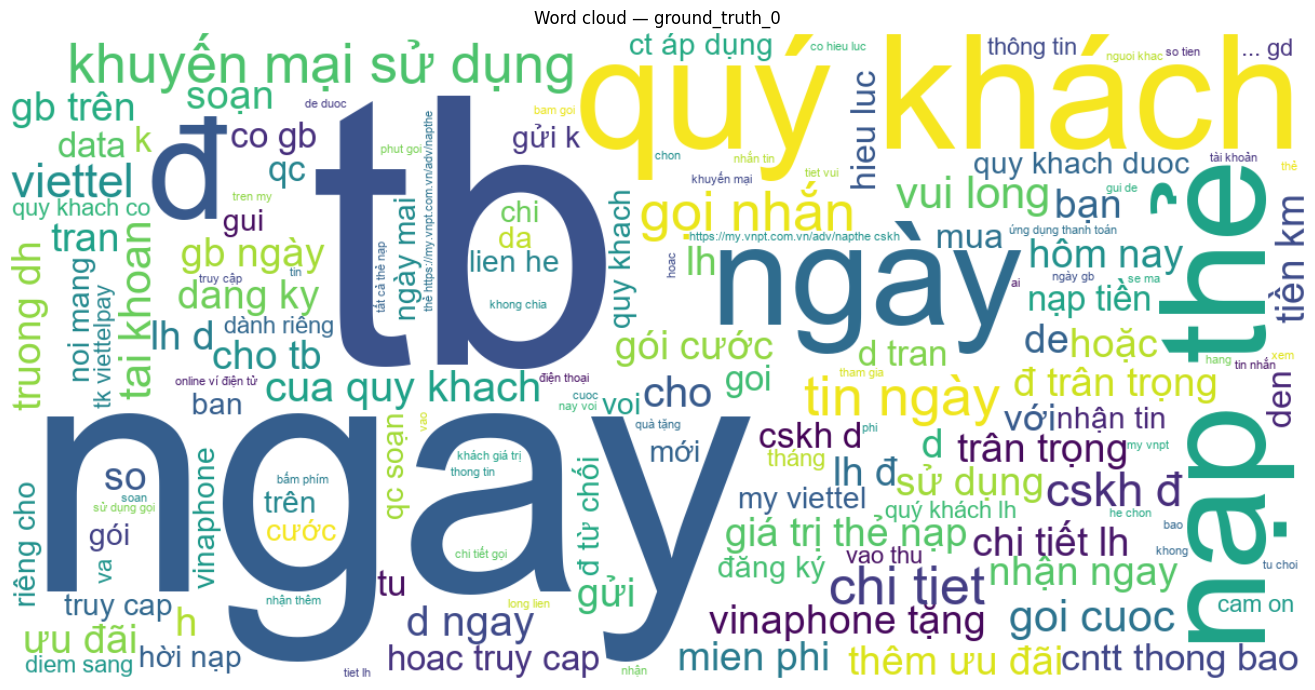

In [75]:
# --- Chạy thử trên ground_truth_0 ---
freq, phrases = build_frequencies(ground_truth_0["content"].dropna(), min_bigram_count=8)
print("Số bigram (phrase):", len(phrases))
print("Top 20:", freq.most_common(20))
show_wordcloud(freq, title="Word cloud — ground_truth_0")

Số bigram (phrase): 55
Top 20: [('bạn', 65), ('k', 55), ('ngay', 52), ('với', 51), ('de', 43), ('tai khoan', 40), ('tin', 38), ('ngày', 37), ('vui long', 36), ('cho', 33), ('ban', 32), ('zalo', 32), ('cua ban', 31), ('đ', 31), ('nhận', 30), ('se', 29), ('vao', 28), ('tiền', 27), ('da', 26), ('công việc', 26)]


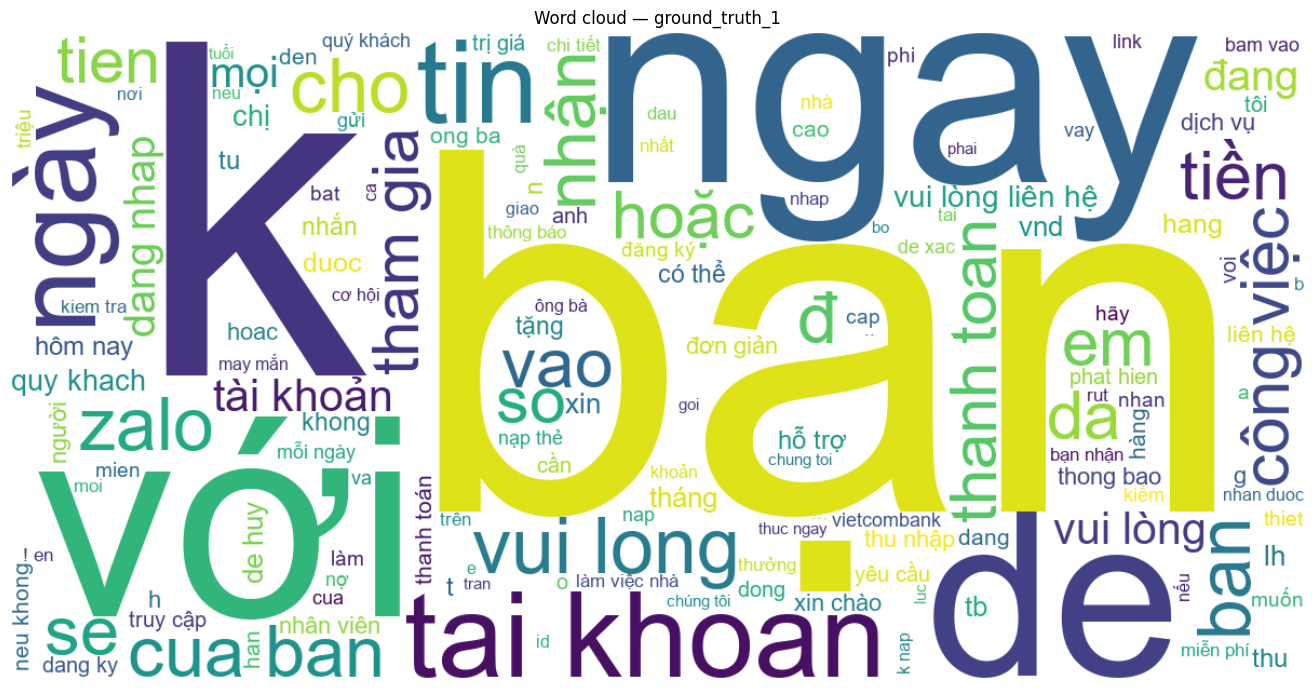

In [76]:
# --- Chạy thử trên ground_truth_1 ---
freq, phrases = build_frequencies(ground_truth_1["content"].dropna(), min_bigram_count=8)
print("Số bigram (phrase):", len(phrases))
print("Top 20:", freq.most_common(20))
show_wordcloud(freq, title="Word cloud — ground_truth_1")

Số bigram (phrase): 836
Top 20: [('ngay', 342), ('vui long', 277), ('hang', 235), ('cho', 180), ('chi tiet', 172), ('lh', 165), ('cua quy khach', 162), ('ban', 152), ('cua ban', 152), ('don hang', 149), ('cua ban la', 144), ('hieu luc', 142), ('ma otp', 135), ('vnd luc', 135), ('goi', 126), ('de', 126), ('thong bao', 121), ('h', 119), ('vnd nd', 118), ('tu h', 116)]


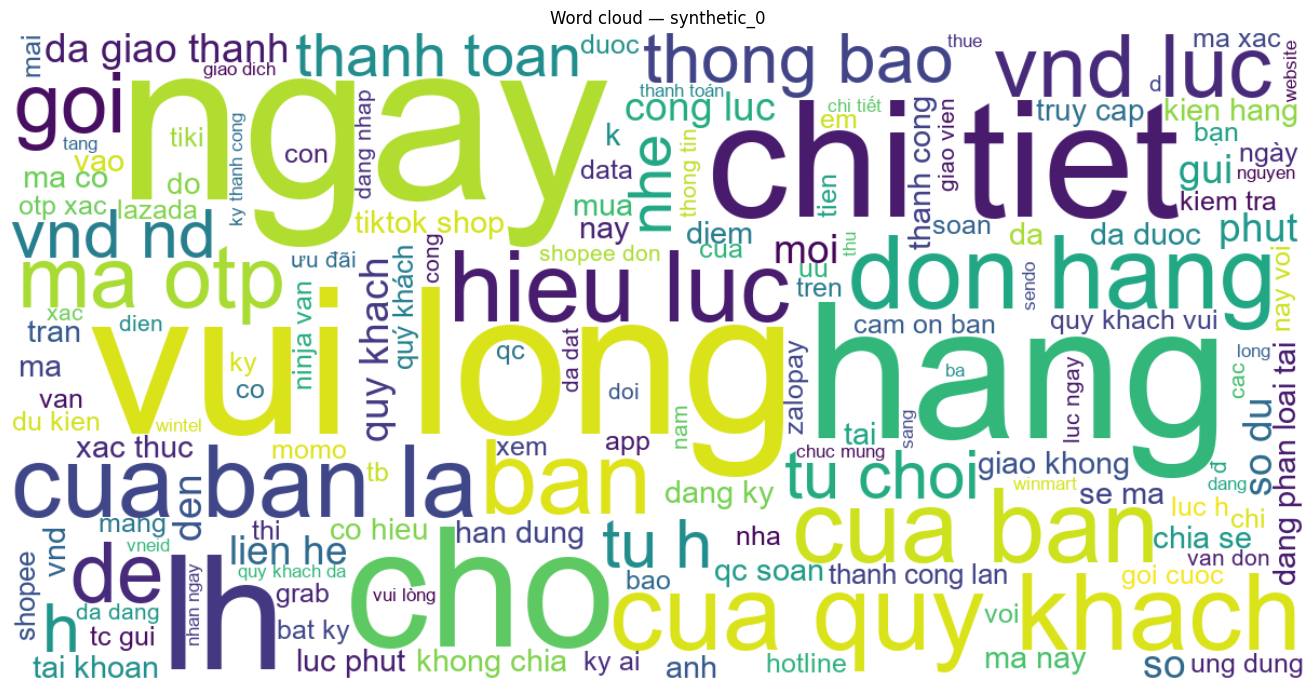

In [77]:
# --- Chạy thử trên synthetic_0 ---
freq, phrases = build_frequencies(synthetic_0["content"].dropna(), min_bigram_count=8)
print("Số bigram (phrase):", len(phrases))
print("Top 20:", freq.most_common(20))
show_wordcloud(freq, title="Word cloud — synthetic_0")

## Thống kê có dấu/không dấu

In [78]:
import re

pattern = re.compile(
r"[àáạảãăắằặẳẵâấầậẩẫèéẹẻẽêếềệểễìíịỉĩòóọỏõôốồộổỗơớờợởỡùúụủũưứừựửữỳýỵỷỹđ]"
)

def has_vietnamese_accent(text):
    return bool(pattern.search(text.lower()))

In [79]:
# Thống kê có dấu/không dấu ground_truth_0
ground_truth_0["has_accent"] = ground_truth_0["content"].apply(has_vietnamese_accent)
stats = ground_truth_0["has_accent"].value_counts()
stats

has_accent
False    1264
True     1063
Name: count, dtype: int64

In [80]:
# Thống kê có dấu/không dấu ground_truth_1
ground_truth_1["has_accent"] = ground_truth_1["content"].apply(has_vietnamese_accent)
stats = ground_truth_1["has_accent"].value_counts()
stats

has_accent
False    148
True     127
Name: count, dtype: int64

In [81]:
# Thống kê có dấu/không dấu synthetic_0
synthetic_0["has_accent"] = synthetic_0["content"].apply(has_vietnamese_accent)
stats = synthetic_0["has_accent"].value_counts()
stats

has_accent
False    2661
True      339
Name: count, dtype: int64

In [82]:
# Thống kê có dấu/không dấu synthetic_1
synthetic_1["has_accent"] = synthetic_1["content"].apply(has_vietnamese_accent)
stats = synthetic_1["has_accent"].value_counts()
stats

has_accent
False    4067
True      933
Name: count, dtype: int64